# Lab 9 - Support Vector Machine and Principal Component Analysis

**Aim:** To implement Support Vector Machine (SVM) for classification and Principal Component Analysis (PCA) for dimensionality reduction, and analyse their effectiveness using real-world datasets.

**Name** Reno Reji Matthew(2547145)


## Part A: Support Vector Machine (SVM)

The Wisconsin Diagnostic Breast Cancer dataset is used for binary classification: benign (B) and malignant (M).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    make_scorer,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


In [2]:
breast_columns = [
    'id', 'diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
    'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean',
    'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se',
    'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se',
    'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst',
    'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst',
    'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

breast_df = pd.read_csv('breast cancer/wdbc.data', header=None, names=breast_columns)
X = breast_df.drop(columns=['id', 'diagnosis'])
y = breast_df['diagnosis']

print('Dataset shape:', breast_df.shape)
print('Missing values:', breast_df.isnull().sum().sum())
print('Class distribution:')
print(y.value_counts())


Dataset shape: (569, 32)
Missing values: 0
Class distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scaling is fitted only on the training data through the pipeline.
linear_search = GridSearchCV(
    make_pipeline(StandardScaler(), SVC(kernel='linear')),
    {'svc__C': [0.01, 0.1, 1, 10, 100]},
    cv=5,
    scoring=make_scorer(f1_score, pos_label='M'),
)
linear_search.fit(X_train, y_train)

best_linear_svm = linear_search.best_estimator_
linear_predictions = best_linear_svm.predict(X_test)

print('Best C:', linear_search.best_params_['svc__C'])
print('Best cross-validation F1 score:', round(linear_search.best_score_, 4))


Best C: 0.1
Best cross-validation F1 score: 0.9575


                Accuracy  Precision  Recall  F1 Score
Linear (tuned)    0.9825        1.0  0.9524    0.9756


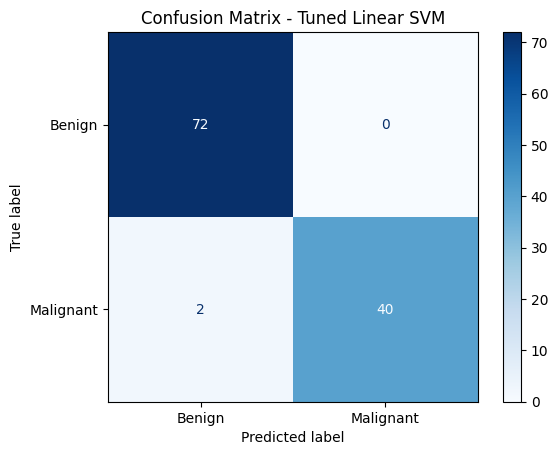

In [4]:
def classification_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, pos_label='M'),
        'Recall': recall_score(y_true, y_pred, pos_label='M'),
        'F1 Score': f1_score(y_true, y_pred, pos_label='M'),
    }

linear_results = pd.DataFrame([classification_metrics(y_test, linear_predictions)], index=['Linear (tuned)'])
print(linear_results.round(4))

ConfusionMatrixDisplay.from_predictions(y_test, linear_predictions, display_labels=['Benign', 'Malignant'], cmap='Blues')
plt.title('Confusion Matrix - Tuned Linear SVM')
plt.show()


In [5]:
# Kernel comparison using the same training and test split.
kernel_results = {}
for kernel in ['linear', 'rbf', 'poly']:
    model = make_pipeline(StandardScaler(), SVC(kernel=kernel, C=linear_search.best_params_['svc__C']))
    model.fit(X_train, y_train)
    kernel_results[kernel] = classification_metrics(y_test, model.predict(X_test))

kernel_results = pd.DataFrame(kernel_results).T
print(kernel_results.round(4))


        Accuracy  Precision  Recall  F1 Score
linear    0.9825        1.0  0.9524    0.9756
rbf       0.9474        1.0  0.8571    0.9231
poly      0.8246        1.0  0.5238    0.6875


### Observation

The tuned linear SVM gives strong classification performance after feature scaling. Precision, recall and F1 score evaluate malignant-case predictions, while the confusion matrix shows the exact correct and incorrect classifications. The kernel comparison shows whether a non-linear decision boundary improves this dataset.


## Part B: Principal Component Analysis (PCA)

The Wine dataset has 13 numerical features and three wine classes.


In [6]:
wine_columns = [
    'class', 'alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
    'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins',
    'color_intensity', 'hue', 'od280_od315', 'proline'
]

wine_df = pd.read_csv('wine/wine.data', header=None, names=wine_columns)
X_wine = wine_df.drop(columns='class')
y_wine = wine_df['class']
X_wine_scaled = StandardScaler().fit_transform(X_wine)

print('Dataset shape:', wine_df.shape)
print('Missing values:', wine_df.isnull().sum().sum())
print('Number of original features:', X_wine.shape[1])


Dataset shape: (178, 14)
Missing values: 0
Number of original features: 13


In [7]:
pca_all = PCA().fit(X_wine_scaled)
explained_variance = pd.DataFrame({
    'Principal Component': [f'PC{i}' for i in range(1, 14)],
    'Explained Variance Ratio': pca_all.explained_variance_ratio_,
    'Cumulative Explained Variance': pca_all.explained_variance_ratio_.cumsum(),
})

components_for_95 = (explained_variance['Cumulative Explained Variance'] < 0.95).sum() + 1
print(explained_variance.round(4))
print(f'\nMinimum components for at least 95% variance: {components_for_95}')


   Principal Component  Explained Variance Ratio  \
0                  PC1                    0.3620   
1                  PC2                    0.1921   
2                  PC3                    0.1112   
3                  PC4                    0.0707   
4                  PC5                    0.0656   
5                  PC6                    0.0494   
6                  PC7                    0.0424   
7                  PC8                    0.0268   
8                  PC9                    0.0222   
9                 PC10                    0.0193   
10                PC11                    0.0174   
11                PC12                    0.0130   
12                PC13                    0.0080   

    Cumulative Explained Variance  
0                          0.3620  
1                          0.5541  
2                          0.6653  
3                          0.7360  
4                          0.8016  
5                          0.8510  
6                  

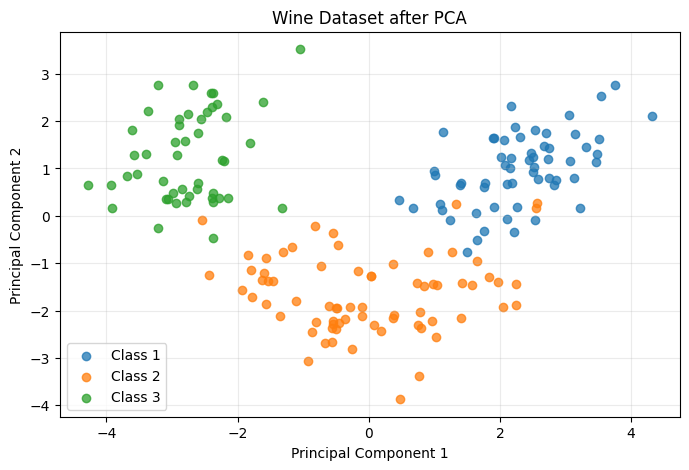

        Dataset  Number of features Information retained Computational efficiency
       Original                  13                 100%                 Baseline
PCA transformed                   2               55.41%    84.62% fewer features


In [8]:
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_wine_scaled)
variance_two_components = pca_2.explained_variance_ratio_.sum()

plt.figure(figsize=(8, 5))
for wine_class in sorted(y_wine.unique()):
    subset = y_wine == wine_class
    plt.scatter(X_pca[subset, 0], X_pca[subset, 1], label=f'Class {wine_class}', alpha=0.75)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Wine Dataset after PCA')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

comparison = pd.DataFrame({
    'Dataset': ['Original', 'PCA transformed'],
    'Number of features': [X_wine.shape[1], 2],
    'Information retained': ['100%', f'{variance_two_components:.2%}'],
    'Computational efficiency': ['Baseline', f'{(1 - 2 / X_wine.shape[1]):.2%} fewer features'],
})
print(comparison.to_string(index=False))


In [9]:
loadings = pd.DataFrame(
    pca_2.components_.T,
    index=X_wine.columns,
    columns=['PC1 loading', 'PC2 loading']
)
print('Feature loadings for the first two principal components:')
print(loadings.round(3))
print(f'\nPC1 and PC2 together retain {variance_two_components:.2%} of the total variance.')


Feature loadings for the first two principal components:
                      PC1 loading  PC2 loading
alcohol                     0.144        0.484
malic_acid                 -0.245        0.225
ash                        -0.002        0.316
alcalinity_of_ash          -0.239       -0.011
magnesium                   0.142        0.300
total_phenols               0.395        0.065
flavanoids                  0.423       -0.003
nonflavanoid_phenols       -0.299        0.029
proanthocyanins             0.313        0.039
color_intensity            -0.089        0.530
hue                         0.297       -0.279
od280_od315                 0.376       -0.164
proline                     0.287        0.365

PC1 and PC2 together retain 55.41% of the total variance.


### PCA interpretation

PC1 captures the largest possible variation in the standardized wine features, and PC2 captures the next-largest independent variation. Their feature loadings show which original measurements contribute most to each component. PCA reduces storage and computation and helps visualization, but can lose information, is sensitive to scaling, and its components may be less interpretable than original features. It is commonly used for visualization, compression, noise reduction and preprocessing.


## Extra Credit: Linear Discriminant Analysis (LDA)


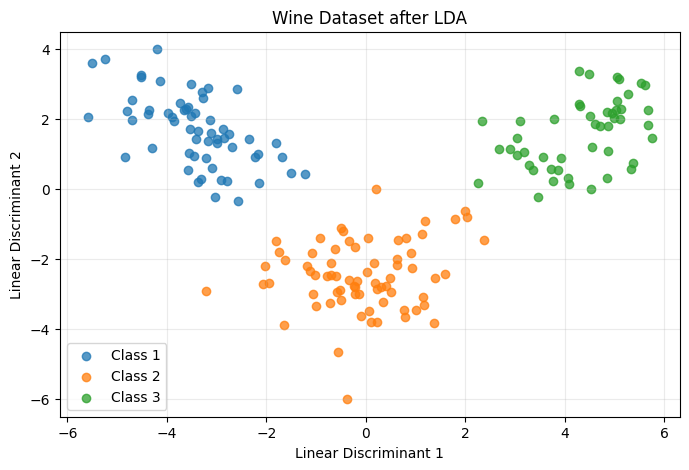

LDA reduces the data to 2 discriminants (the maximum possible for 3 classes).
PCA is unsupervised and preserves variance; LDA is supervised and aims to maximize class separability.


In [10]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_wine_scaled, y_wine)

plt.figure(figsize=(8, 5))
for wine_class in sorted(y_wine.unique()):
    subset = y_wine == wine_class
    plt.scatter(X_lda[subset, 0], X_lda[subset, 1], label=f'Class {wine_class}', alpha=0.75)
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.title('Wine Dataset after LDA')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print('LDA reduces the data to 2 discriminants (the maximum possible for 3 classes).')
print('PCA is unsupervised and preserves variance; LDA is supervised and aims to maximize class separability.')


### Final observation

PCA finds directions with the greatest overall variance without using class labels. LDA uses the labels and usually separates the wine classes more clearly. Therefore, PCA is useful for general compression and visualization, whereas LDA is preferable when labelled class separation is the main goal.
